## 12. Employee Skills Table

Our current five datasets don't contain what skills each employee has. Without that, a real skill-gap calculation is impossible.

- If employee skill data exists → use it directly

- If it doesn't → build a controlled table for the MVP

In [11]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

PROCESSED_PATH = '../data/processed'

emp = pd.read_csv(f'{PROCESSED_PATH}/employee_attrition_processed.csv')
# Load role_master for reference (will be used in Notebook 13 for gap analysis)
role_master = pd.read_csv(f'{PROCESSED_PATH}/role_master.csv')

print(f'Employees: {emp.shape[0]}')
print(f'Roles: {role_master.shape[0]}')
print(f'Unique JobRoles: {emp["JobRole"].nunique()}')
print(f'Departments: {emp["Department"].unique().tolist()}')

Employees: 500
Roles: 1016
Unique JobRoles: 13
Departments: ['Finance', 'Sales', 'Support', 'HR', 'IT', 'Marketing']


## 1. Check for Existing Skill Data

Do we have any employee skill data? Let's check.

In [12]:
eng = pd.read_csv(f'{PROCESSED_PATH}/engagement_processed.csv')
print('Training programs:')
print(eng['Training Program Name'].value_counts().head(10))
print()
print('Training types:', eng['Training Type'].unique())
print('Training outcomes:', eng['Training Outcome'].unique())
print()
print('-> No direct skill data. Building controlled table.')

Training programs:
Training Program Name
Communication Skills      673
Project Management        609
Technical Skills          579
Leadership Development    574
Customer Service          565
Name: count, dtype: int64

Training types: <StringArray>
['Internal', 'External']
Length: 2, dtype: str
Training outcomes: <StringArray>
['Failed', 'Incomplete', 'Completed', 'Passed']
Length: 4, dtype: str

-> No direct skill data. Building controlled table.


## 2. Build Controlled Employee Skills Table

Based on JobRole and Department, with random variation. **Disclaimer**: Synthetic data for MVP.

In [13]:
dept_skills = {
    'IT': ['Python', 'SQL', 'AWS', 'Docker', 'Linux', 'Git', 'Java', 'REST APIs', 'CI/CD', 'Kubernetes', 'Azure'],
    'Sales': ['CRM', 'Salesforce', 'Excel', 'PowerPoint', 'Negotiation', 'Lead Generation', 'Pipeline Management', 'HubSpot'],
    'Support': ['Customer Service', 'Ticketing Systems', 'Zendesk', 'Communication', 'Problem Solving', 'Excel'],
    'Finance': ['Excel', 'Financial Analysis', 'SAP', 'QuickBooks', 'SQL', 'PowerPoint', 'Budgeting', 'Forecasting'],
    'HR': ['Excel', 'Workday', 'BambooHR', 'Recruitment', 'Onboarding', 'Compliance', 'Communication'],
    'Marketing': ['Google Analytics', 'SEO', 'Excel', 'PowerPoint', 'Social Media', 'Content Creation', 'HubSpot']
}

common_skills = ['Microsoft Excel', 'Microsoft Word', 'Communication', 'Teamwork', 'Problem Solving']

print('Skill pools defined:')
for dept, skills in dept_skills.items():
    print(f'  {dept}: {len(skills)} skills')

Skill pools defined:
  IT: 11 skills
  Sales: 8 skills
  Support: 6 skills
  Finance: 8 skills
  HR: 7 skills
  Marketing: 7 skills


In [14]:
np.random.seed(42)
employee_skills = []

for _, row in emp.iterrows():
    emp_id = row['EmployeeID']
    dept = row['Department']
    
    dept_pool = dept_skills.get(dept, [])
    
    if len(dept_pool) >= 3:
        n_dept = np.random.randint(3, min(7, len(dept_pool) + 1))
        assigned_dept = list(np.random.choice(dept_pool, size=n_dept, replace=False))
    elif len(dept_pool) > 0:
        assigned_dept = list(dept_pool)
    else:
        assigned_dept = []
    
    n_common = np.random.randint(2, 5)
    assigned_common = list(np.random.choice(common_skills, size=n_common, replace=False))
    
    all_skills = list(set(assigned_dept + assigned_common))
    
    for skill in all_skills:
        employee_skills.append({'EmployeeID': emp_id, 'current_skill': skill})

skills_df = pd.DataFrame(employee_skills)
print(f'Generated {len(skills_df)} skill records')
print(f'Unique employees: {skills_df["EmployeeID"].nunique()}')
print(f'Unique skills: {skills_df["current_skill"].nunique()}')
print(f'Skills per employee: {skills_df.groupby("EmployeeID").size().describe().round(1)}')

Generated 3646 skill records
Unique employees: 500
Unique skills: 41
Skills per employee: count    500.0
mean       7.3
std        1.4
min        4.0
25%        6.0
50%        7.0
75%        8.0
max       10.0
dtype: float64


## 3. Employee Skills Preview

In [15]:
print('First 20 rows:')
print(skills_df.head(20).to_string(index=False))
print()
print('Employee 101 skills:', skills_df[skills_df['EmployeeID'] == 101]['current_skill'].tolist())

First 20 rows:
 EmployeeID       current_skill
          1               Excel
          1     Problem Solving
          1         Forecasting
          1           Budgeting
          1      Microsoft Word
          1          PowerPoint
          1            Teamwork
          1  Financial Analysis
          1     Microsoft Excel
          2     Problem Solving
          2     Lead Generation
          2      Microsoft Word
          2         Negotiation
          2       Communication
          2          Salesforce
          2          PowerPoint
          2                 CRM
          2 Pipeline Management
          3     Problem Solving
          3      Microsoft Word

Employee 101 skills: [np.str_('Onboarding'), np.str_('BambooHR'), np.str_('Problem Solving'), np.str_('Teamwork'), np.str_('Compliance')]


## 4. Skill Coverage Analysis

In [16]:
skill_counts = skills_df['current_skill'].value_counts()
print('Top 15 Skills:')
print(skill_counts.head(15).to_string())

Top 15 Skills:
current_skill
Communication         347
Problem Solving       326
Microsoft Word        314
Microsoft Excel       299
Teamwork              291
Excel                 252
PowerPoint            143
HubSpot               107
SQL                    82
Ticketing Systems      66
Customer Service       64
Zendesk                63
Salesforce             56
Compliance             54
Financial Analysis     53


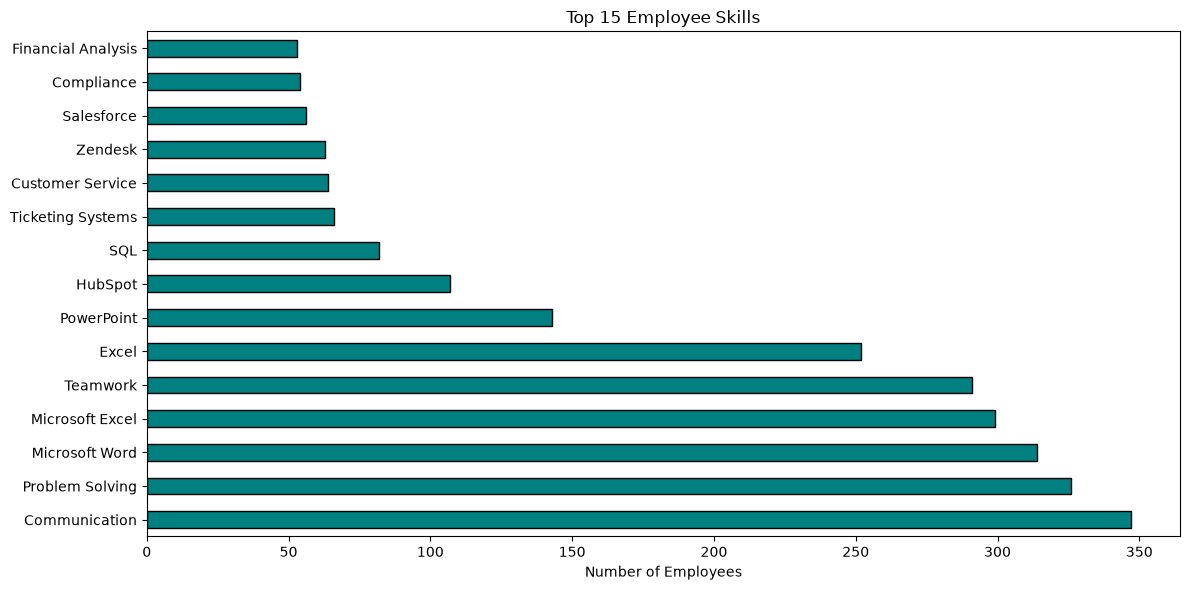

Saved: ../docs/employee_skills_distribution.png


In [17]:
fig, ax = plt.subplots(figsize=(12, 6))
skill_counts.head(15).plot(kind='barh', ax=ax, color='teal', edgecolor='black')
ax.set_title('Top 15 Employee Skills')
ax.set_xlabel('Number of Employees')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../docs/employee_skills_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../docs/employee_skills_distribution.png')

## 5. Skills by Department

In [18]:
emp_skill_counts = skills_df.groupby('EmployeeID').size().reset_index(name='skill_count')
emp_skill_counts = emp_skill_counts.merge(emp[['EmployeeID', 'Department']], on='EmployeeID')

dept_skills_avg = emp_skill_counts.groupby('Department')['skill_count'].mean().sort_values()
print('Avg Skills per Employee by Department:')
print(dept_skills_avg.round(2).to_string())

Avg Skills per Employee by Department:
Department
Support      6.59
Sales        7.16
HR           7.30
IT           7.35
Finance      7.71
Marketing    7.74


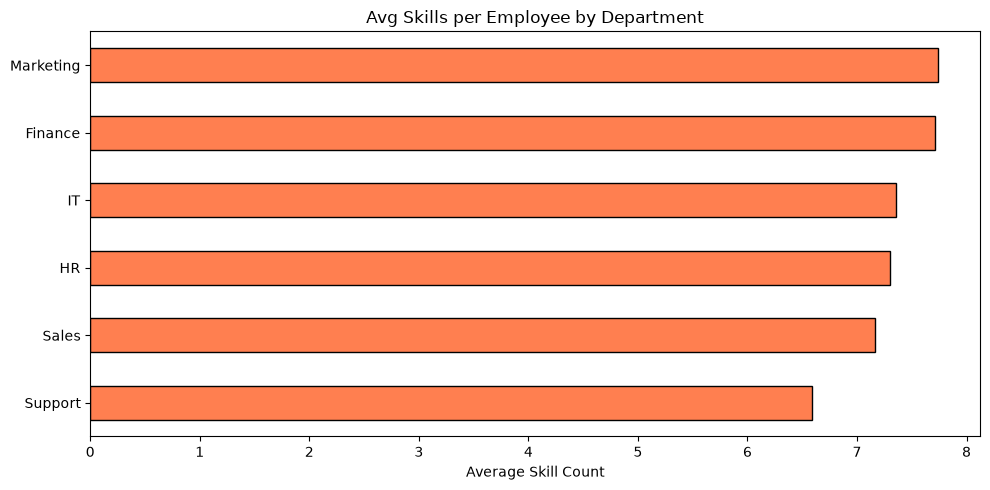

Saved: ../docs/skills_by_department.png


In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
dept_skills_avg.plot(kind='barh', ax=ax, color='coral', edgecolor='black')
ax.set_title('Avg Skills per Employee by Department')
ax.set_xlabel('Average Skill Count')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../docs/skills_by_department.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../docs/skills_by_department.png')

## 6. Save Employee Skills Table

In [20]:
skills_df.to_csv(f'{PROCESSED_PATH}/employee_skills.csv', index=False)

print(f'Saved employee_skills.csv: {skills_df.shape}')

Saved employee_skills.csv: (3646, 2)


## Summary

### What We Found

- **No direct employee skill data exists** in the current datasets

- Engagement data has training programs, but not individual skills

### What We Built

- **Controlled employee skills table** based on **Department** (used as a proxy, since mapping individual `JobRole` to O*NET codes requires manual effort deferred to a later phase)

- Each employee is assigned 4-8 skills (a mix of department-specific technical skills and universal common skills)

- **Disclaimer**: Synthetic data for MVP. Replace with real skill data when available.

### Files Created

- `data/processed/employee_skills.csv` — employee_id, current_skill mapping

- `docs/employee_skills_distribution.png` — top skills across employees

- `docs/skills_by_department.png` — skills per department